# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

### Откройте файл с данными и изучите общую информацию

In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
try:
    df = pd.read_csv('./datasets/real_estate_data.csv', sep='\t')
except:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/real_estate_data.csv', sep='\t')

Рассмотрим общую информацию о столбцах датасета

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

Построим гистограммы для всех столбцов датасета

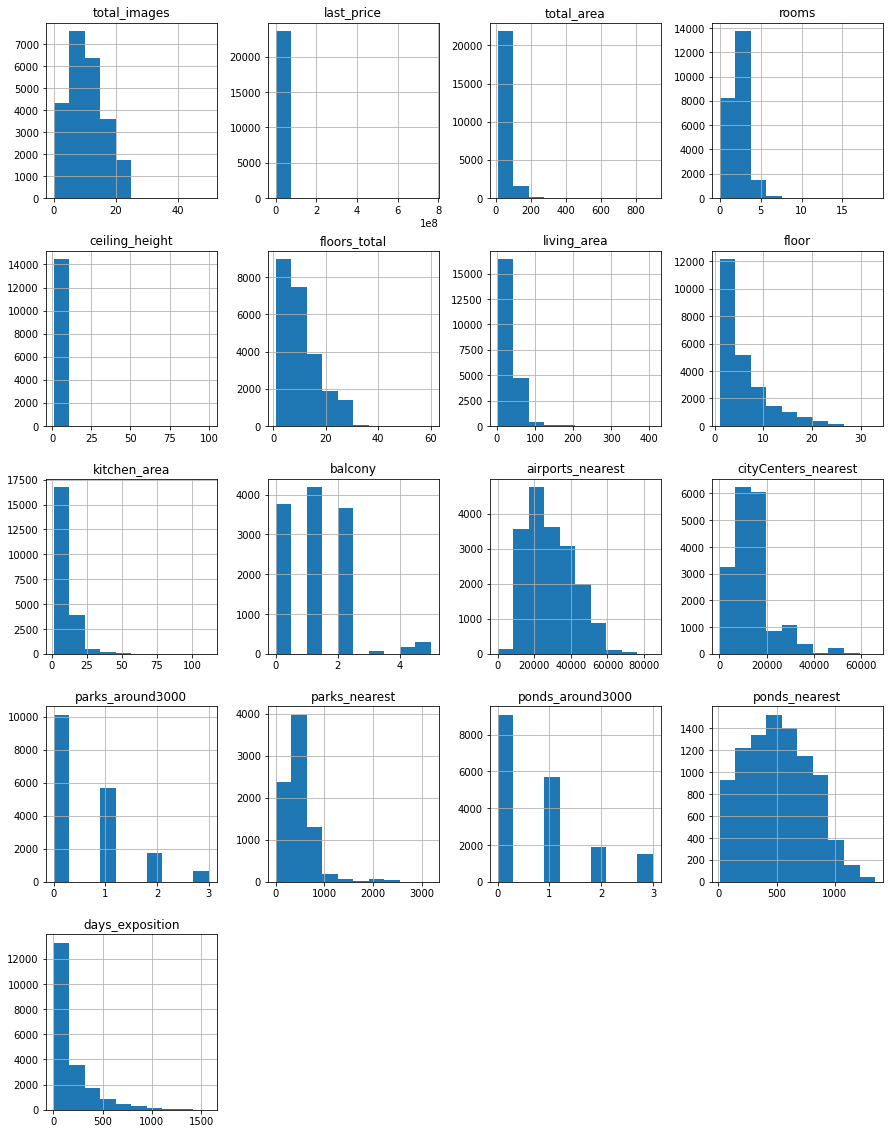

In [4]:
df.hist(figsize=(15, 20));

#### Вывод
В результате выполнения первичного изучения информации о датасете:
 - Загружен датасет;
 - Получено общее представление о столбцах датасета;
 - Построены гистограммы по всем столбцам датасета;
 - Обнаружены столбцы, тип данных которых не соответствует их содержанию;
 - Обнаружены пропуски в данных;
 - Выявлены аномалии в данных, в некоторых столбцах.

### Выполните предобработку данных

Посчитаем количество пропусков в каждом столбце

In [5]:
df.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

Заменим пропуски в столбцах, где подстановку можно логично объяснить

Заполним пропуски в высоте потолков медианным значением

In [6]:
df['ceiling_height'].fillna(df['ceiling_height'].median(), inplace=True)

Пропуск в этом столбце мог быть вызван особенностями работы клиента. Например если недвижимость не может являться апартаментом (дом, студия и т.д.) то значения пропущена. Будем считать объявление с пропусками не апартаментами

In [7]:
df['is_apartment'].fillna(0, inplace=True)

То же самое что и предыдущий пункт, можно объяснить особенностями заполнения объявления

In [8]:
df['balcony'].fillna(0, inplace=True)

Если недвижимость является студией, у неё нет кухни

In [9]:
df.loc[df['studio'] == True, 'kitchen_area'] = 0

Заполним жилую и кухонную площади медианными значениями т.к. медиана устойчива к выбросам

In [10]:
df['living_area'].fillna(df['living_area'].median(), inplace=True)

In [11]:
df['kitchen_area'].fillna(df['kitchen_area'].median(), inplace=True)

С текстовым значением работать удобнее чем с пропуском

In [12]:
df['locality_name'].fillna('Неизвестно', inplace=True)

Будем считать, что квартиры с пропущенным значением количества этажей в доме будут на последнем этаже. Это не сильно должно повлиять на статистические характеристики выборки

In [13]:
df.loc[df['floors_total'].isna(), 'floors_total'] = df['floor']

Перепроверим заполнение пропусков

In [14]:
df.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height              0
floors_total                0
living_area                 0
floor                       0
is_apartment                0
studio                      0
open_plan                   0
kitchen_area                0
balcony                     0
locality_name               0
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

Все пропуски могли быть вызваны особенностями работы клиента (веб-приложения) через которое подаются объявления. Вполне возможно что пользователь может просто не заполнить необязательные поля в форме подачи объявления. Теория выглядит более правдоподобной, если учесть, что в таких важных значениях объявления, как цена, количество картинок, площадь и мета-параметр даты подачи объявления - не содержат пропусков

Посмотрим на типы данных столбцов, выделим столбцы, типы которых необходимо изменить

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        23699 non-null  float64
 6   floors_total          23699 non-null  float64
 7   living_area           23699 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          23699 non-null  object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          23699 non-null  float64
 13  balcony               23699 non-null  float64
 14  locality_name         23699 non-null  object 
 15  airports_nearest   

Поменяем типы у столбцов `first_day_exposition`, `floors_total`, `is_apartment`, `balcony`, `parks_around3000`, `ponds_around3000`, `days_exposition`

Посмотрим формат даты у столбца с датой подачи объявления

In [16]:
df.iloc[0]['first_day_exposition']

'2019-03-07T00:00:00'

In [17]:
df['first_day_exposition'] = pd.to_datetime(df['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')

In [18]:
df['floors_total'] = df['floors_total'].astype('Int64')
df['is_apartment'] = df['is_apartment'].astype('bool')
df['balcony'] = df['balcony'].astype('Int64')
df['parks_around3000'] = df['parks_around3000'].astype('Int64')
df['ponds_around3000'] = df['ponds_around3000'].astype('Int64')
df['days_exposition'] = np.floor(pd.to_numeric(df['days_exposition'], errors='coerce')).astype('Int64')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23699 non-null  int64         
 1   last_price            23699 non-null  float64       
 2   total_area            23699 non-null  float64       
 3   first_day_exposition  23699 non-null  datetime64[ns]
 4   rooms                 23699 non-null  int64         
 5   ceiling_height        23699 non-null  float64       
 6   floors_total          23699 non-null  Int64         
 7   living_area           23699 non-null  float64       
 8   floor                 23699 non-null  int64         
 9   is_apartment          23699 non-null  bool          
 10  studio                23699 non-null  bool          
 11  open_plan             23699 non-null  bool          
 12  kitchen_area          23699 non-null  float64       
 13  balcony         

Типы данных были успешно заменены. Типы нужно менять для возможности выполнения подходящих операций над данными, для более удобной работы. Например, поменяв тип данных со строки над датой, нам открывается весь набор методов типа DateTime, что облегчает работу. То же самое работае и с типом данных Int и т.д.

Исключим неявные дупликаты из столбца с названием населённого пункта

In [20]:
df['locality_name'].unique()

array(['Санкт-Петербург', 'посёлок Шушары', 'городской посёлок Янино-1',
       'посёлок Парголово', 'посёлок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок городского типа Красный Бор', 'Гатчина', 'поселок Мурино',
       'деревня Фёдоровское', 'Выборг', 'Кронштадт', 'Кировск',
       'деревня Новое Девяткино', 'посёлок Металлострой',
       'посёлок городского типа Лебяжье',
       'посёлок городского типа Сиверский', 'поселок Молодцово',
       'поселок городского типа Кузьмоловский',
       'садовое товарищество Новая Ропша', 'Павловск',
       'деревня Пикколово', 'Всеволожск', 'Волхов', 'Кингисепп',
       'Приозерск', 'Сестрорецк', 'деревня Куттузи', 'посёлок Аннино',
       'поселок городского типа Ефимовский', 'посёлок Плодовое',
       'деревня Заклинье', 'поселок Торковичи', 'поселок Первомайское',
       'Красное Село', 'посёлок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', '

Посмотря на уникальные значения, можно увидеть, что названия населённых пунктов начинаются с большой буквы, а приписки "посёлок, деревня, станцция" - с маленькой. Уберём все слова из подстроки, начинающиеся с маленькой буквы

In [21]:
def remove_lowercase_words(text):
    # Используем регулярное выражение для поиска слов, начинающихся с маленькой буквы
    return ' '.join(word for word in text.split() if not word[0] == word[0].lower() or word[0].isnumeric())

df['locality_name'] = df['locality_name'].apply(remove_lowercase_words)

df['locality_name'].unique()

array(['Санкт-Петербург', 'Шушары', 'Янино-1', 'Парголово', 'Мурино',
       'Ломоносов', 'Сертолово', 'Петергоф', 'Пушкин', 'Кудрово',
       'Коммунар', 'Колпино', 'Красный Бор', 'Гатчина', 'Фёдоровское',
       'Выборг', 'Кронштадт', 'Кировск', 'Новое Девяткино',
       'Металлострой', 'Лебяжье', 'Сиверский', 'Молодцово',
       'Кузьмоловский', 'Новая Ропша', 'Павловск', 'Пикколово',
       'Всеволожск', 'Волхов', 'Кингисепп', 'Приозерск', 'Сестрорецк',
       'Куттузи', 'Аннино', 'Ефимовский', 'Плодовое', 'Заклинье',
       'Торковичи', 'Первомайское', 'Красное Село', 'Понтонный',
       'Сясьстрой', 'Старая', 'Лесколово', 'Новый Свет', 'Сланцы',
       'Путилово', 'Ивангород', 'Шлиссельбург', 'Никольское',
       'Зеленогорск', 'Сосновый Бор', 'Оржицы', 'Кальтино', 'Романовка',
       'Бугры', 'Рощино', 'Кириши', 'Луга', 'Волосово', 'Отрадное',
       'Павлово', 'Оредеж', 'Копорье', 'Молодёжное', 'Тихвин', 'Победа',
       'Нурма', 'Синявино', 'Тосно', 'Стрельна', 'Бокситогорск',

Дубликаты успешно убраны

#### Выводы:
В результате предобработки данных:     
- Были заполнены пропуски в столбцах, где замена поддаётся логическому объяснению. Пропуски можно объяснить тем, что при заполнении формы подачи объявления в веб приложении, поля с этими данными являлись необязательными.    
- Типы данных столбцов с неподходящими типами были изменены, на те типы, которые подходят по смыслу. Это облегчит дальнейшую работу.    
- Были убраны неявные дупликаты в столбце с названием населённого пункта

### Добавьте в таблицу новые столбцы

Добавим столбец со значением цены за квадратный метр. Поделим цену продажи на общую площадь, оставив 2 знака после запятой

In [22]:
df['square_meter_price'] = (df['last_price'] / df['living_area']).round(2)

Добавим стобцы с днём, месяцем и годом подачи объявления. Для этого извлечём данные из уже имеющегося столбца

In [23]:
df['first_day_of_week_exposition'] = df['first_day_exposition'].dt.dayofweek

In [24]:
df['first_month_exposition'] = df['first_day_exposition'].dt.month

In [25]:
df['first_year_exposition'] = df['first_day_exposition'].dt.year

Добавим столбец с "типом" этажа

In [26]:
def get_floor_type(floor, total_floors):
    if floor == 1:
        return 'первый'
    elif floor == total_floors:
        return 'последний'
    else:
        return 'другой'
        
df['floor_type'] = df.apply(lambda row: get_floor_type(row['floor'], row['floors_total']), axis=1)

Добавим столбец, который будет содержать расстояние от центра в километрах

In [27]:
df['distance_to_center_km'] = (df['cityCenters_nearest'] / 1000).round().astype('Int64')

#### Выводы:
В результате проделанной работы в данном пункте были добавлены соответствующие столбцы, благодаря которым можно получить более детальный взгляд на имеющиеся данные.

### Проведите исследовательский анализ данных

Рассмотрим общую площадь недвижимости

<AxesSubplot:>

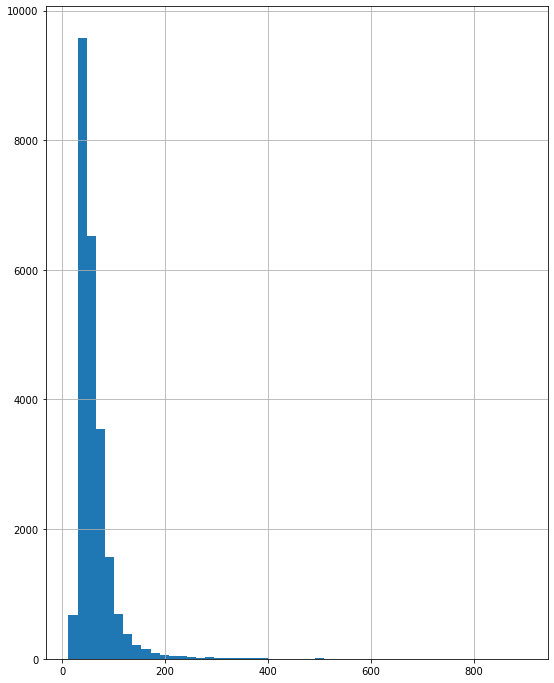

In [28]:
df['total_area'].hist(bins=50, figsize=(9, 12))

In [29]:
df['total_area'].describe()

count    23699.000000
mean        60.348651
std         35.654083
min         12.000000
25%         40.000000
50%         52.000000
75%         69.900000
max        900.000000
Name: total_area, dtype: float64

На графике и в описании данных видны аномальные значения в 900 квадратныых метров жилой площади. Явный выброс, его стоит убрать

<AxesSubplot:>

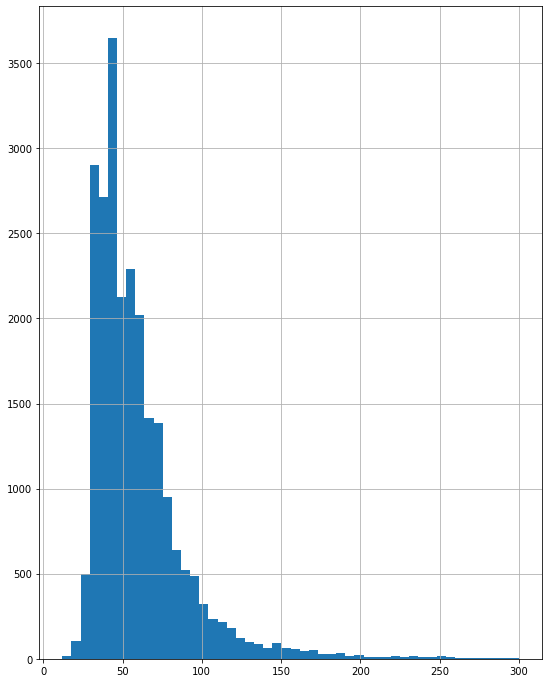

In [30]:
df.query('total_area <= 300', inplace=True)
df['total_area'].hist(bins=50, figsize=(9, 12))

На графике видно, что больше всего квартир с общей площадью ～50 квадратных метров. "Больших" квартир меньше, но их всё ещё больше чем "маленьких"

Рассмотрим варрирование жилой площади недвижимости на рынке

<AxesSubplot:>

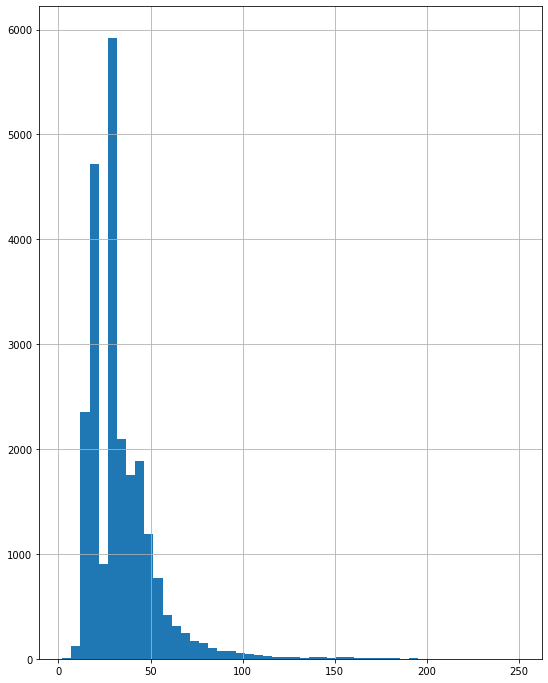

In [31]:
df['living_area'].hist(bins=50, figsize=(9, 12))

In [32]:
df['living_area'].describe()

count    23638.000000
mean        33.712592
std         19.080786
min          2.000000
25%         19.000000
50%         30.000000
75%         41.000000
max        250.000000
Name: living_area, dtype: float64

Редких и аномальных значений не обнаружено, однако стоит осмотреть поподробнее "середину" графика

<AxesSubplot:>

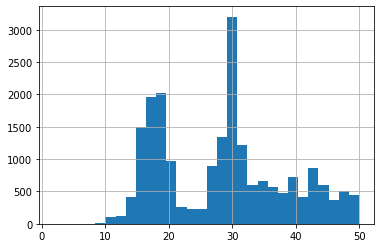

In [33]:
df.query('living_area <= 50')['living_area'].hist(bins=30)

При детальном рассмотрении, можно увидеть что квартир с жилой площадью в 22 - 26 квадратных метров меньше, чем остальных в этом диапазоне. Может быть связано с уникальной застройкой / квартиры находятся в старых домах

Подкоректируем столбец с жилой площадью, убрав "коробки" с жилой площадью в 2 квадратных метра

<AxesSubplot:>

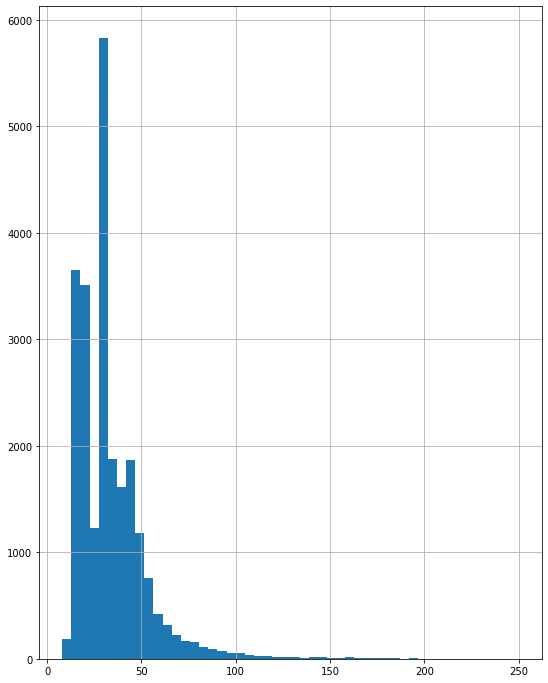

In [34]:
df.query('living_area >= 8 and living_area <= 290', inplace=True)
df['living_area'].hist(bins=50, figsize=(9, 12))

Рассмотрим площади кухонь

<AxesSubplot:>

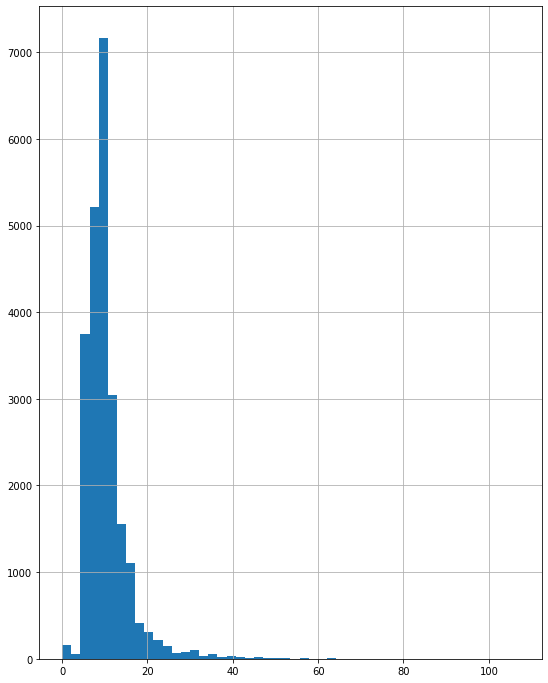

In [35]:
df['kitchen_area'].hist(bins=50, figsize=(9, 12))

In [36]:
df['kitchen_area'].describe()

count    23630.000000
mean        10.306548
std          5.473037
min          0.000000
25%          7.200000
50%          9.010000
75%         11.400000
max        107.000000
Name: kitchen_area, dtype: float64

Стоит убрать длинный хвост от 60 метров

<AxesSubplot:>

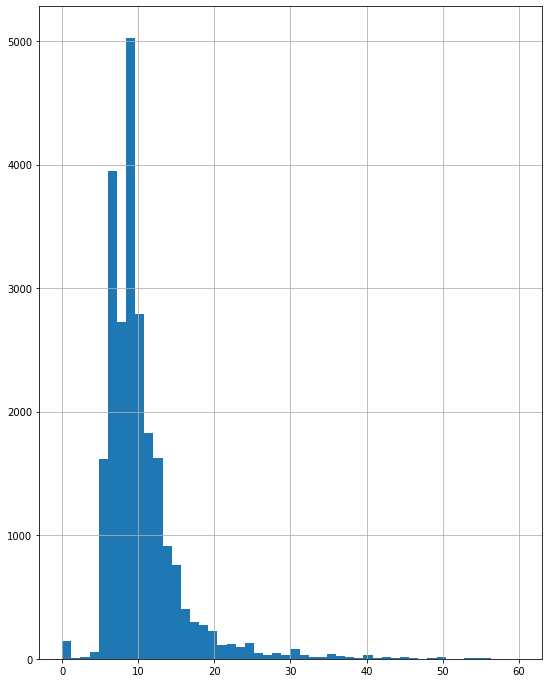

In [37]:
df.query('kitchen_area <= 60', inplace=True)
df['kitchen_area'].hist(bins=50, figsize=(9, 12))

Рассмотрим столбец с ценой

<AxesSubplot:>

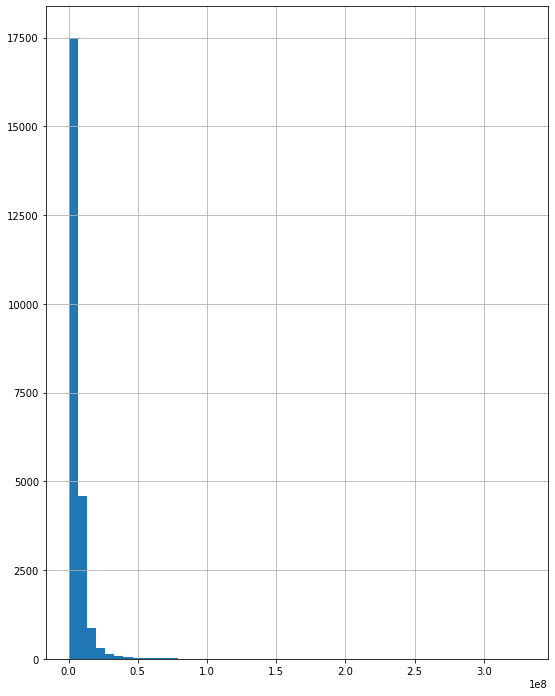

In [38]:
df['last_price'].hist(bins=50, figsize=(9, 12))

In [39]:
df['last_price'].describe()

count    2.361200e+04
mean     6.268000e+06
std      7.585739e+06
min      1.219000e+04
25%      3.400000e+06
50%      4.600000e+06
75%      6.750000e+06
max      3.300000e+08
Name: last_price, dtype: float64

Есть значения с высокой ценой, однако не стоит модифицировать столбец, который мы будем рассматривать как основной критерий в дальнейших исследованиях. Это сильно может повлиять на параметры выборки и сделать исследование нерепрезентативным

Рассмотрим колличество комнат в недвижимости

<AxesSubplot:>

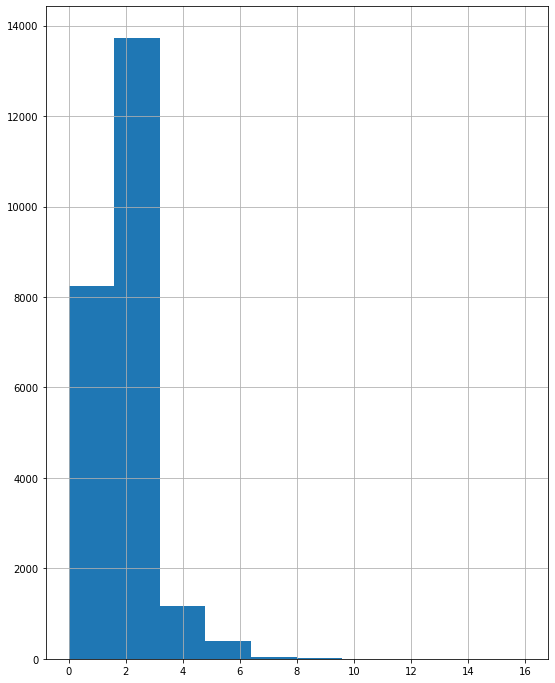

In [40]:
df['rooms'].hist(bins=10, figsize=(9, 12))

In [41]:
df['rooms'].describe()

count    23612.000000
mean         2.058403
std          1.045013
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         16.000000
Name: rooms, dtype: float64

Уберём квартиры в которых больше 12 комнат

<AxesSubplot:>

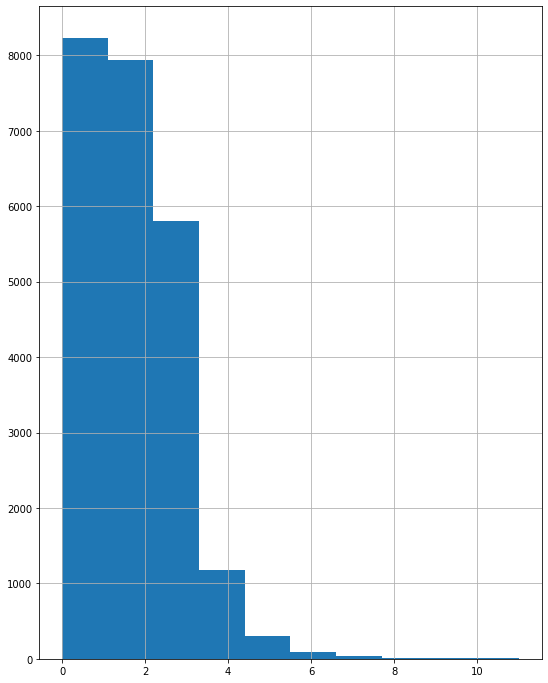

In [42]:
df.query('rooms <= 12', inplace=True)
df['rooms'].hist(bins=10, figsize=(9, 12))

Рассмотрим высоту потолков

<AxesSubplot:>

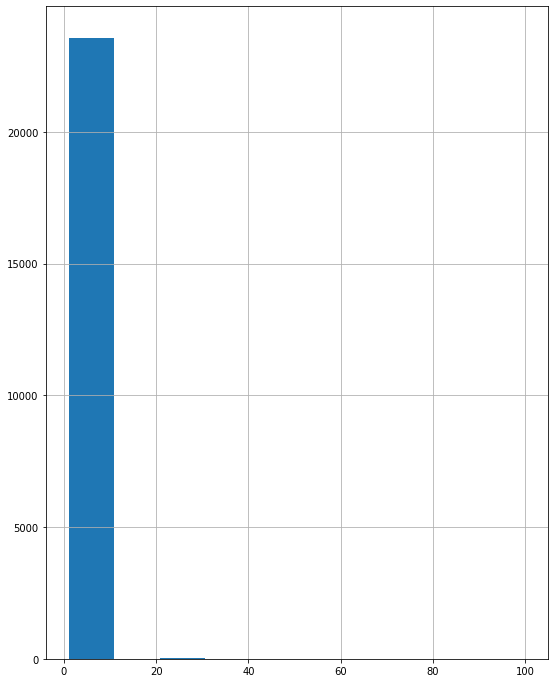

In [43]:
df['ceiling_height'].hist(bins=10, figsize=(9, 12))

Гистограмма выглядит очень странно, посмотрим на данные поближе

In [44]:
df['ceiling_height'].describe()

count    23610.000000
mean         2.722812
std          0.989145
min          1.000000
25%          2.600000
50%          2.650000
75%          2.700000
max        100.000000
Name: ceiling_height, dtype: float64

Делаем вывод, что в некоторых объявлениях высота потолков указана без запятой (напр. 24 вместо 2,4) исправим

In [45]:
df.loc[df['ceiling_height'] >= 4, 'ceiling_height'] /= 10

In [46]:
df['ceiling_height'].describe()

count    23610.000000
mean         2.682234
std          0.241642
min          0.400000
25%          2.600000
50%          2.650000
75%          2.700000
max         10.000000
Name: ceiling_height, dtype: float64

Уберём выбросы

In [47]:
df.query('ceiling_height <= 8 and ceiling_height >= 2.5', inplace=True)

<AxesSubplot:>

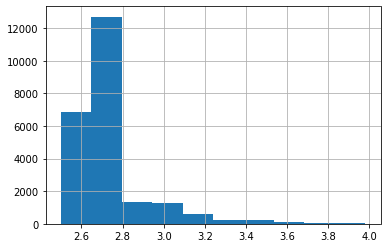

In [48]:
df['ceiling_height'].hist()

Рассмотрим "тип" этажа в квартирах

<AxesSubplot:>

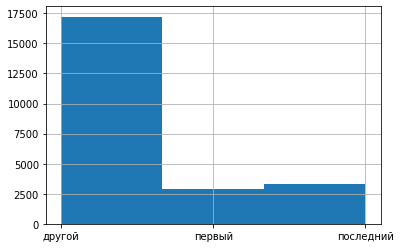

In [49]:
df['floor_type'].hist(bins=3)

Каких либо интересных инсайтов в данных нет. Разве что, квартиры на крайних этажах (что снизу, что сверху) продают гораздо реже, чем квартиры "посередине"

In [50]:
df['floor_type'].describe()

count      23449
unique         3
top       другой
freq       17218
Name: floor_type, dtype: object

Рассмотрим количество этажей в датасете

<AxesSubplot:>

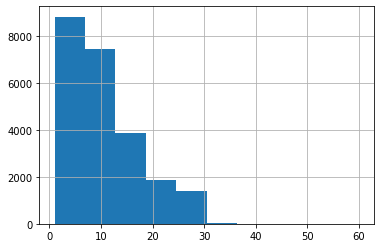

In [51]:
df['floors_total'].hist()

In [52]:
df['floors_total'].describe()

count    23449.000000
mean        10.712227
std          6.600973
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64

Домов в 40 - 60 этажей очень-очень мало, на гистограмме видем "хвост", стоит от него избавиться

<AxesSubplot:>

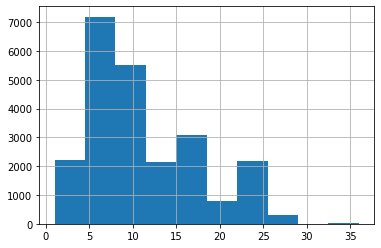

In [53]:
df.query('floors_total <= 40', inplace=True)
df['floors_total'].hist()

Рассмотрим удалённость квартир от центра (в километрах)

<AxesSubplot:>

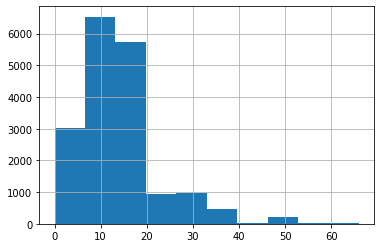

In [54]:
df['distance_to_center_km'].hist()

In [55]:
df['distance_to_center_km'].describe()

count    17972.000000
mean        14.237147
std          8.597787
min          0.000000
25%          9.000000
50%         13.000000
75%         16.000000
max         66.000000
Name: distance_to_center_km, dtype: float64

Больше всего недвижимости продаётся в удалении от центра. Это могут быть ново-застроенные микрорайоны, которые сейчас популярны и квартиры там продаются "пачками" по много

Рассмотрим столбец, содержащий расстояние до ближайшего парка

<AxesSubplot:>

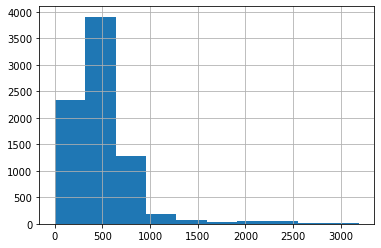

In [56]:
df['parks_nearest'].hist()

In [57]:
df['parks_nearest'].describe()

count    7939.000000
mean      491.012596
std       343.136744
min         1.000000
25%       288.000000
50%       453.000000
75%       613.000000
max      3190.000000
Name: parks_nearest, dtype: float64

Аномалий в данном наборе данных нет. Замен не требуется

Рассмотрим дни, в которые выставлялись объявления. По выходным пользователи неактивно публикуют продажи. Самые активные дни - вторник и четверг. В рабочей неделе самый неактивный - понедельник

<AxesSubplot:>

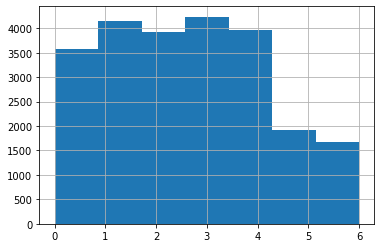

In [58]:
df['first_day_of_week_exposition'].hist(bins=7)

Рассмотрим сколько квартир продавалось в различные месяцы. В декабре пользователи ведут себя не очень активно, однако в следующем месяце можно наблюдать "бум" предложений, который медленно затухает и превращается в провал в мае. Затем, после небольшого скачка в июне, активность потихоньку нарастает, в октябре приближаясь по значениям в "бум", замеченный ранней весной. Под конец года наблюдается резкий спад, который продолжается и в январе следующего года

<AxesSubplot:>

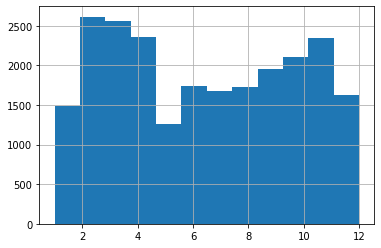

In [59]:
df['first_month_exposition'].hist(bins=12)

В 2014 году из-за объективных причин можно наблюдать "смерть" рынка недвижимости. Рынок небольшими скачками "воскресал", а в 2017 - 2018 году, недвижимость пользовалась огромным успехом, однако в 2019 году - рынок вернулся в прежнее положение

<AxesSubplot:>

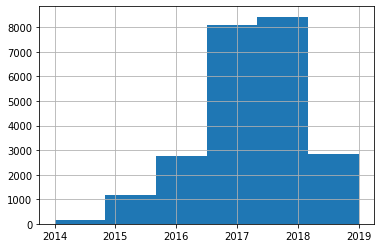

In [60]:
df['first_year_exposition'].hist(bins=6)

<AxesSubplot:>

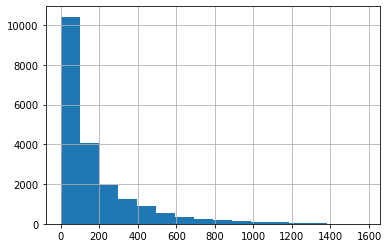

In [61]:
df['days_exposition'].hist(bins=16)

In [62]:
df['days_exposition'].describe()

count    20314.000000
mean       180.270109
std        219.192896
min          1.000000
25%         45.000000
50%         95.000000
75%        230.000000
max       1580.000000
Name: days_exposition, dtype: float64

Медианное значение продажи квартир - 95 дней, среднее - 180 дней. На среднее значение не стоит ориентироваться, т.к. выбросы оттягивают его вверх. Таким образом можно считать что продажи менее 95 дней - быстрые. Необычайно долгими являются продажи больше 230 дней

Рассмотрим как общая площадь влияет на цену квартир

<AxesSubplot:xlabel='total_area'>

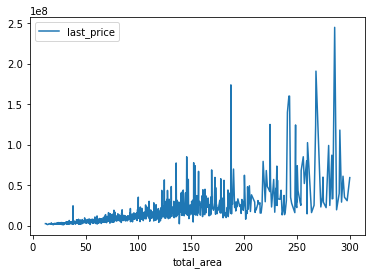

In [63]:
df.pivot_table(index='total_area', values='last_price').plot()

Смотря на график, можно сделать вывод: чем больше площадь помещения, тем больше цена на него. Цена прямо пропорциональна площади

Рассмотрим как жилая площадь влияет на цену

<AxesSubplot:xlabel='living_area'>

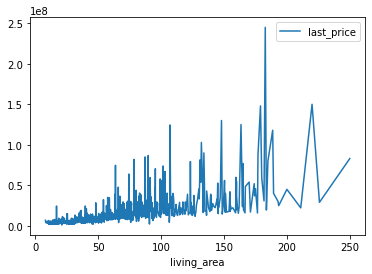

In [64]:
df.pivot_table(index='living_area', values='last_price').plot()

Как и в случае с общей площадью, цена прямо пропорциональна жилой площади недвижимости

Рассмотрим, как размеры кухни влияют на цену

<AxesSubplot:xlabel='kitchen_area'>

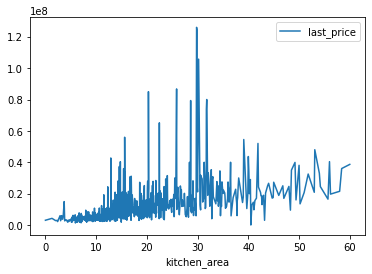

In [65]:
df.pivot_table(index='kitchen_area', values='last_price').plot()

Площадь кухни не является исключением, цена всё также растёт с площадью, однако можно заметить, что помещения с площадью кухни в 30м самые дорогие

Рассмотрим как количество комнат влияет на цену

<AxesSubplot:xlabel='rooms'>

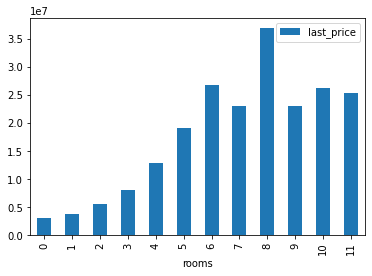

In [66]:
df.pivot_table(index='rooms', values='last_price', aggfunc='mean').plot(kind='bar')

Начиная со студий, заканчивая 6-комнатными квартирами - цена растёт, однако 7-комнатная недвижимость стоит дешевле, 6-комнатная. Затем самая дорогая недвижимость в среднем - с 8 комнатами. Из этого можно сделать вывод, что чем больше комнат - тем больше цена объекта

Рассмотрим, как тип этажа влияет на цену

<AxesSubplot:xlabel='floor_type'>

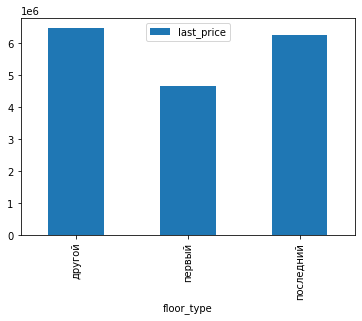

In [67]:
df.pivot_table(index='floor_type', values='last_price', aggfunc='mean').plot(kind='bar')

Квартиры на первом этаже самые дешёвые. Между последними и иными этажами разница маленькая, однако самые дорогие квартиры - посередие

Рассмотрим как день подачи объявления влияет на цену

<AxesSubplot:xlabel='first_day_of_week_exposition'>

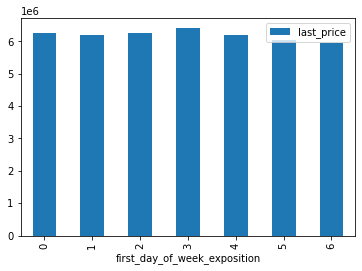

In [68]:
df.pivot_table(index='first_day_of_week_exposition', values='last_price', aggfunc='mean').plot(kind='bar')

Квартиры, выставленные в выходные - самыё дешёвые, причём в воскресение дешевле чем в субботу. Самые дорогие квартиры - выставленные в четверг и в понедельник. После четверга можно наблюдать удешевление в ценах объектов

Рассмотрим как цена варируется от месяца

<AxesSubplot:xlabel='first_month_exposition'>

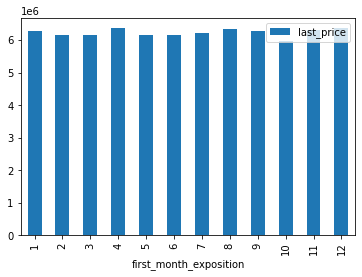

In [69]:
df.pivot_table(index='first_month_exposition', values='last_price', aggfunc='mean').plot(kind='bar')

Самые дешёвые квартиры - выставленные в октябре. В конце года и в апреле - квартиры самые дорогие

Рассмотрим как цена менялась с годами

<AxesSubplot:xlabel='first_year_exposition'>

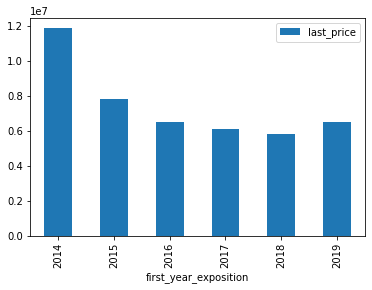

In [70]:
df.pivot_table(index='first_year_exposition', values='last_price', aggfunc='mean').plot(kind='bar')

С 2014 на 2015 год можно наблюдать резкое удешивление средней цены недвижимости. Этот спад продолжался до 2019 года, в котором можно наблюдать небольшой, но рост цены

In [71]:
df['price_per_square'] = df['last_price'] / df['total_area']
cities_count = df.pivot_table(index='locality_name', values='last_price', aggfunc='count')
top_cities = cities_count.sort_values(by='last_price', ascending=False).head(10).index
df_filtered = df.query('locality_name in @top_cities')
prices_mean = df_filtered.pivot_table(index='locality_name', values='price_per_square', aggfunc=['count', 'mean'])
prices_mean.sort_values(by=('mean', 'price_per_square'), ascending=False).head(10)

,count,mean
,price_per_square,price_per_square
locality_name,,
Санкт-Петербург,15532,113854.778962
Пушкин,360,102880.917365
Кудрово,471,95326.179139
Парголово,326,90205.423758
Мурино,589,86061.677014
Шушары,440,78677.364217
Колпино,336,75352.475583
Гатчина,306,68799.627791


В Санкт-Петербурге самая высокая цена за 1 квадратный метр. С небольшим отрывом в 10000 рублей идёт Пушкин. В тройку лидеров по цене за квадратный метр также входит Кудрово. Самая низкая цена за квадратный метр в гроде Выборг, в размере 58250 тысяч за метр в квадрате

<AxesSubplot:xlabel='distance_to_center_km'>

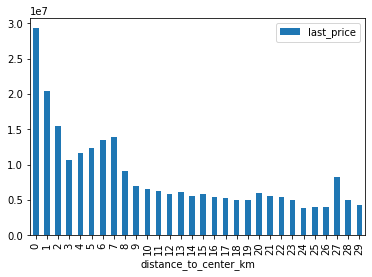

In [72]:
spb_estate = df[df['locality_name'] == 'Санкт-Петербург']
mean_price_each_km_from_center = spb_estate.pivot_table(index='distance_to_center_km', values='last_price', aggfunc='mean')
mean_price_each_km_from_center.plot(kind='bar')

Самые дорогие квартиры - в центре. Затем, с удалением от центра, цена падает. С 3 до 7 километров цена снова возрастает. Падение цены продолжается с 7 до 19 километров. Следующий подъём цена наблюдается на 20 километре и 27 километре. Цена на 27 километре резко взлетает вверх. Это может быть связано с нахождением на этой дистанции котеджного посёлка или новой застройкой, где цена в среднем выше

### Напишите общий вывод

В результате выполнения проекта: 
 - была проведена предобработка данных, были выделены новые столбцы, помогающие в исследовании, удалены пропуски.
 - Был выполнен исследовательский анализ данных в котором были:
   - выявлены и удалены аномальные значения,
   - определены факторы, влияющие на полную стоимость объекта,
   - изучено время продажи недвижимости
   - высчитана и ранжирована средняя цена за квадратный метр в разных городах Ленинградской области
   - исследована зависимость удалённости недвижимости от центра и её цены

**Чек-лист готовности проекта**

Поставьте 'x' в выполненных пунктах. Далее нажмите Shift+Enter.

- [x]  Файл с данными открыт.
- [x]  Файл с данными изучен: выведены первые строки, использован метод `info()`, построены гистограммы.
- [x]  Найдены пропущенные значения.
- [x]  Пропущенные значения заполнены там, где это возможно.
- [x]  Объяснено, какие пропущенные значения обнаружены.
- [x]  В каждом столбце установлен корректный тип данных.
- [x]  Объяснено, в каких столбцах изменён тип данных и почему.
- [x]  Устранены неявные дубликаты в названиях населённых пунктов.
- [ ]  Обработаны редкие и выбивающиеся значения (аномалии).
- [x]  В таблицу добавлены новые параметры:
       – цена одного квадратного метра;
       – день публикации объявления (0 - понедельник, 1 - вторник и т. д.);
       – месяц публикации объявления;
       – год публикации объявления;
       – тип этажа квартиры (значения — «первый», «последний», «другой»);
       – расстояние до центра города в километрах.
- [x]  Изучены и описаны параметры:
        - общая площадь;
        - жилая площадь;
        - площадь кухни;
        - цена объекта;
        - количество комнат;
        - высота потолков;
        - тип этажа квартиры («первый», «последний», «другой»);
        - общее количество этажей в доме;
        - расстояние до центра города в метрах;
        - расстояние до ближайшего парка.
- [x]  Выполнено задание «Изучите, как быстро продавались квартиры (столбец `days_exposition`)»:
    - построена гистограмма;
    - рассчитаны среднее и медиана;
    - описано, сколько обычно занимает продажа и указано, какие продажи можно считать быстрыми, а какие — необычно долгими.
- [x]  Выполнено задание «Определите факторы, которые больше всего влияют на общую (полную) стоимость объекта». Построены графики, которые показывают зависимость цены от параметров:
        - общая площадь;
        - жилая площадь;
        - площадь кухни;
        - количество комнат;
        - тип этажа, на котором расположена квартира (первый, последний, другой);
        - дата размещения (день недели, месяц, год).
- [x]  Выполнено задание «Посчитайте среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений»:
    - выделены населённые пункты с самой высокой и низкой стоимостью квадратного метра.
- [x]  Выполнено задание «Выделите квартиры в Санкт-Петербурге с помощью столбца `locality_name` и вычислите их среднюю стоимость на разном удалении от центра»:
    -  учтён каждый километр расстояния, известны средние цены квартир в одном километре от центра, в двух и так далее;
    -  описано, как стоимость объекта зависит от расстояния до центра города;
    -  построен график изменения средней цены для каждого километра от центра Петербурга.
- [x]  На каждом этапе сделаны промежуточные выводы.
- [x]  В конце проекта сделан общий вывод.